In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd 

In [3]:
house = fetch_california_housing()

In [4]:
df = pd.DataFrame(house.data, columns=house.feature_names)

In [5]:
df['HouseValue'] = house.target

In [6]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [18]:
X = df.drop('HouseValue', axis=1).values
y = df['HouseValue'].values

# What i want to do is to compare the result of sklearn model with my scratch model results
## Using my scratch model first

In [19]:
from models.linear_regression import LinearRegression

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [37]:
## Getting the mean and std 
scaler.mean_.squeeze(), scaler.scale_.squeeze()

(array([ 3.87067100e+00,  2.86394864e+01,  5.42899974e+00,  1.09667515e+00,
         1.42547674e+03,  3.07065516e+00,  3.56318614e+01, -1.19569704e+02]),
 array([1.89977569e+00, 1.25852527e+01, 2.47411320e+00, 4.73899376e-01,
        1.13243469e+03, 1.03857980e+01, 2.13590065e+00, 2.00348319e+00]))

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_rem, y_train, y_rem = train_test_split(X_scaled, y, train_size=0.5, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)

del X_rem, y_rem

In [22]:
model_1 = LinearRegression(learning_rate=0.01, lambda_=0.002, iterations=1000)

In [23]:
model_1.fit(X_train, y_train)

Iteration 0, Cost: 2.7523068672588087
Iteration 100, Cost: 0.645194313121787
Iteration 200, Cost: 0.35616968221017764
Iteration 300, Cost: 0.3106434652401302
Iteration 400, Cost: 0.2990689311677337
Iteration 500, Cost: 0.29294553275474744
Iteration 600, Cost: 0.28823868904206845
Iteration 700, Cost: 0.28428467375811184
Iteration 800, Cost: 0.280907041693796
Iteration 900, Cost: 0.27801211684951915


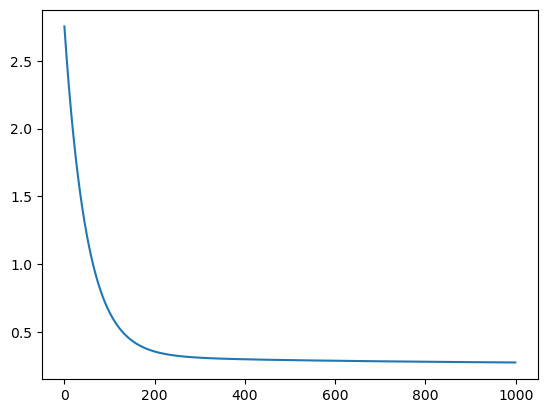

In [25]:
import matplotlib.pyplot as plt
plt.plot(model_1.cost_history)

In [40]:
y_pred= model_1.predict(X_test)
y_pred

array([1.5934298 , 1.20319819, 0.76506183, ..., 1.29055872, 2.05239089,
       1.59162915])

In [47]:
from sklearn.metrics import mean_squared_error, accuracy_score

print("ypred mean squared error:", mean_squared_error(y_test, y_pred))

ypred mean squared error: 0.5542819682813697


In [45]:
## Testing oon cross validation set 

y_pred_cv = model_1.predict(X_val)
y_pred_cv

array([1.14270972, 2.62140724, 1.55713413, ..., 1.79707441, 2.4038388 ,
       3.90338745])

In [46]:
print('ypred_cv mean squared error:', mean_squared_error(y_test, y_val))

ypred_cv mean squared error: 2.6606790536409104
